In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from scipy.special import expit
from scipy.stats import skewnorm, gaussian_kde
from pathlib import Path

rng = np.random.default_rng(1)

## Helpers

In [3]:
def inv_logit(x):
    return expit(x)

def normalize(p):
    p = np.asarray(p, dtype=float)
    s = p.sum()
    if s <= 0:
        raise ValueError("Probabilities must sum to > 0")
    return p / s

In [4]:
#data helpers

def build_pop_distributions_population_differences(age_range: np.ndarray) -> np.ndarray:
    """Create population array D_popdiff with shape (2, 2, A),
    for 2 populations × 2 genders × |age_range| age bins.

    Pop 1: exponential-like (growing pop)
    Pop 2: skew-normal-like (shrinking pop)
    Both genders share the same age shape within each population.
    """
    A = len(age_range)
    D = np.zeros((2, 2, A), dtype=float)

    # Exponential over 0..100, then subset to the requested age_range (1..90 in R code)
    x_full = np.arange(0, 101)
    rate = 0.04
    exp_pdf_full = rate * np.exp(-rate * x_full)
    exp_pdf = exp_pdf_full[age_range]

    # Skew normal PDF evaluated at 1..100, subset to age_range
    xi, omega, alpha = 30.0, 50.0, 1.0
    x_1_100 = np.arange(1, 101)
    skew_pdf_full = skewnorm.pdf(x_1_100, a=alpha, loc=xi, scale=omega)
    skew_pdf = skew_pdf_full[age_range - 1]

    # Assign to both genders equally within each population
    for g in (0, 1):
        D[0, g, :] = normalize(exp_pdf)
        D[1, g, :] = normalize(skew_pdf)

    return D


def build_pop_distributions_sampling_differences(age_range: np.ndarray) -> np.ndarray:
    """Create population array D_samplediff with shape (2,2,A),
    where both populations have the same exponential age distribution for both genders.
    """
    A = len(age_range)
    D = np.zeros((2, 2, A), dtype=float)

    x_full = np.arange(0, 101)
    rate = 0.04
    exp_pdf_full = rate * np.exp(-rate * x_full)
    exp_pdf = exp_pdf_full[age_range]

    for pop in (0, 1):
        for g in (0, 1):
            D[pop, g, :] = normalize(exp_pdf)

    return D

In [5]:
def simulate_dataset(D: np.ndarray, N: int, age_range: np.ndarray,
                     p_male_pop1: float, p_male_pop2: float,
                     p_logit_culture: np.ndarray, b_age: float, b_gender: float) -> tuple[pd.DataFrame, np.ndarray]:
    """Simulate a combined dataset for two populations given their demographic arrays D.

    D shape: (2 populations, 2 genders, A ages)
    gender coding: 1=male, 2=female (as in original R)
    Returns DataFrame with columns: id, soc_id (1/2), age (1..A), gender (1/2), outcome (0/1)
            and SampleD with shape (2,2,A) giving sample counts per cell.
    """
    A = D.shape[-1]
    df = []

    # Age sampling probabilities by population (use gender 0 slice; genders share same age shape in D)
    p_age_pop1 = normalize(D[0, 0, :])
    p_age_pop2 = normalize(D[1, 0, :])

    # Simulate ages
    ages_pop1 = rng.choice(age_range, size=N, replace=True, p=p_age_pop1)
    ages_pop2 = rng.choice(age_range, size=N, replace=True, p=p_age_pop2)

    # Simulate genders with possibly different sampling probabilities by population
    genders_pop1 = rng.choice([1, 2], size=N, replace=True, p=[p_male_pop1, 1 - p_male_pop1])
    genders_pop2 = rng.choice([1, 2], size=N, replace=True, p=[p_male_pop2, 1 - p_male_pop2])

    # Build dataframe
    df_pop1 = pd.DataFrame({
        "id": np.arange(1, N + 1),
        "soc_id": 1,
        "age": ages_pop1,
        "gender": genders_pop1,
    })
    df_pop2 = pd.DataFrame({
        "id": np.arange(N + 1, 2 * N + 1),
        "soc_id": 2,
        "age": ages_pop2,
        "gender": genders_pop2,
    })
    d = pd.concat([df_pop1, df_pop2], ignore_index=True)

    # Generate outcomes using the logistic regression used in the R code
    # logit p = p_logit_culture[soc-1] + b_age*age + b_gender*(gender-1)
    lin = p_logit_culture[d["soc_id"].values - 1] + b_age * d["age"].values + b_gender * (d["gender"].values - 1)
    p = inv_logit(lin)
    d["outcome"] = rng.binomial(1, p)

    # Sample counts per (pop, gender, age)
    SampleD = np.zeros_like(D)
    for pop in (1, 2):
        for g in (1, 2):
            for a in age_range:
                SampleD[pop - 1, g - 1, a - 1] = int(((d.soc_id == pop) & (d.gender == g) & (d.age == a)).sum())

    return d, SampleD

In [6]:
def compute_true_expected(D: np.ndarray, p_logit_culture: np.ndarray, b_age: float, b_gender: float) -> np.ndarray:
    """Compute the true expected prosociality within each population, given the demographic weights D.

    D shape: (2,2,A)
    Returns array of length 2.
    """
    A = D.shape[-1]
    true_vals = np.zeros(2)
    ages = np.arange(1, A + 1)
    for pop in (0, 1):
        # Weighted sum over gender (a=0/1 -> gender=1/2) and ages 1..A
        weights = D[pop, :, :]
        logits = (
            p_logit_culture[pop]
            + b_gender * np.array([0, 1])[:, None]  # (2,1)
            + b_age * ages[None, :]                 # (1,A)
        )
        probs = inv_logit(logits)
        expect_pos = (weights * probs).sum()
        total = weights.sum()
        true_vals[pop] = expect_pos / total
    return true_vals

In [32]:
#plotting
def plot_age_curves(idata_pop1, idata_pop2, d_list_pop1: dict, d_list_pop2: dict,
                    title_left: str, title_right: str, outpath: Path | None = None):
    """Two panels with age- and gender-specific estimates with 89% intervals.
    Highlights observed vs unobserved age bins per gender.
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, idata, dlist, title in [
        (axes[0], idata_pop1, d_list_pop1, title_left),
        (axes[1], idata_pop2, d_list_pop2, title_right),
    ]:
        pm_m = idata.posterior["pred_p_m"].values  # (chain, draw, MA)
        pm_f = idata.posterior["pred_p_f"].values
        q_m = np.quantile(pm_m.reshape(-1, pm_m.shape[-1]), [0.055, 0.5, 0.945], axis=0)
        q_f = np.quantile(pm_f.reshape(-1, pm_f.shape[-1]), [0.055, 0.5, 0.945], axis=0)

        MA = pm_m.shape[-1]
        ages = np.arange(1, MA + 1)
        obs_m = np.isin(ages, np.unique(dlist["age"][dlist["gender"] == 1]))
        obs_f = np.isin(ages, np.unique(dlist["age"][dlist["gender"] == 2]))

        for k, (q, dx, obs_mask, marker, label) in enumerate([
            (q_m, -0.25, obs_m, "o", "Male"),
            (q_f, +0.25, obs_f, "^", "Female"),
        ]):
            x_obs = ages[obs_mask] + dx
            x_un  = ages[~obs_mask] + dx
            med, lo, hi = q[1], q[0], q[2]

            ax.errorbar(x_obs, med[obs_mask], yerr=[med[obs_mask]-lo[obs_mask], hi[obs_mask]-med[obs_mask]],
                        fmt=marker, alpha=1.0, label=label if k==0 else None)
            ax.errorbar(x_un, med[~obs_mask], yerr=[med[~obs_mask]-lo[~obs_mask], hi[~obs_mask]-med[~obs_mask]],
                        fmt=marker, alpha=0.2)

        ax.set_title(title)
        ax.set_xlim(0.5, MA + 0.5)
        ax.set_ylim(0.0, 1.0)
        ax.set_xlabel("Age category")
        ax.grid(alpha=0.2)

    axes[0].set_ylabel("Probability of prosocial choice")
    axes[0].legend(loc="upper left")
    fig.tight_layout()
    if outpath is not None:
        fig.savefig(outpath, dpi=200)
    return fig


def pyramid_plot(ax, left: np.ndarray, right: np.ndarray, ages: np.ndarray,
                  title: str, left_label: str = "Male", right_label: str = "Female"):
    """Simple population pyramid using horizontal bars.
    left/right: arrays of the same length; will be normalized to percentages.
    """
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    left_pct = 100 * left / left.sum()
    right_pct = 100 * right / right.sum()
    y = np.arange(len(ages))

    ax.barh(y, -left_pct, align='center')
    ax.barh(y, right_pct, align='center')
    ax.set_yticks(y[::10], ages[::10])
    ax.set_xlabel('% of population')
    ax.set_title(title)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.invert_yaxis()


def plot_density(ax, samples: np.ndarray, true_value: float | None = None,
                 *, face: str | None = None, edge: str | None = None,
                 label: str | None = None, alpha: float = 0.35,
                 lw: float = 2.0, linestyle: str = '-'):
    """Flexible density plot helper.
    - If `face` is provided, draws a filled KDE with that facecolor and `alpha`.
    - Always draws an outline curve using `edge` (or `face` if `edge` is None).
    - If `true_value` is given, draws a vertical reference line.
    """
    kde = gaussian_kde(samples)
    xs = np.linspace(0, 1, 512)
    ys = kde(xs)

    # Filled area (optional)
    if face not in (None, 'none'):
        ax.fill_between(xs, ys, facecolor=face, alpha=alpha, label=label)
        outline_label = None
    else:
        outline_label = label

    # Outline curve
    edge_color = edge if edge is not None else (face if face not in (None, 'none') else 'k')
    ax.plot(xs, ys, color=edge_color, lw=lw, linestyle=linestyle, label=outline_label)

    if true_value is not None:
        ax.axvline(true_value, linestyle='--', linewidth=2, color='k')
    ax.set_xlim(0, 1)
    ax.set_yticks([])
    plt.show()

In [11]:
#models

def fit_empirical(outcome: np.ndarray, draws=2000, tune=2000, chains=4, seed=1) -> az.InferenceData:
    """Empirical Bernoulli-logit model: y ~ Bernoulli(logit(p_logit)),
    with p = logistic(p_logit) as a deterministic for convenience.
    """
    y = np.asarray(outcome, dtype="int8")
    with pm.Model() as m:
        p_logit = pm.Normal("p_logit", mu=0.0, sigma=5.0)
        pm.Bernoulli("y", logit_p=p_logit, observed=y)
        p = pm.Deterministic("p", pm.math.sigmoid(p_logit))
        idata = pm.sample(draws=draws, tune=tune, chains=chains, random_seed=seed,
                          target_accept=0.99, max_treedepth=13)
    return idata


def fit_mrp_gp(age, gender, outcome, P_Pop, P_other, MA, draws=2000, tune=2000, chains=4, seed=1):
    """Gaussian-process MRP with age effects by gender, plus poststratification.
    gender: 1=male, 2=female (converted to 0/1)
    age:    1..MA (converted to 0..MA-1)
    P_Pop, P_other: 2×MA matrices of weights (counts or proportions)
    """
    age = np.asarray(age, dtype=int) - 1
    gender = np.asarray(gender, dtype=int) - 1
    outcome = np.asarray(outcome, dtype="int8")
    P_Pop = np.asarray(P_Pop, dtype=float)
    P_other = np.asarray(P_other, dtype=float)

    idx = np.arange(MA)
    D2_np = ((idx[None, :] - idx[:, None]) ** 2).astype(float) / (MA ** 2)
    I_np = np.eye(MA, dtype=float)

    with pm.Model() as m:
        alpha = pm.Normal("alpha", mu=0.0, sigma=3.0, shape=2)
        eta   = pm.Exponential("eta", lam=2.0, shape=2)
        sigma = pm.Exponential("sigma", lam=1.0, shape=2)
        rho   = pm.Beta("rho", alpha=10.0, beta=1.0, shape=2)

        D2 = pt.as_tensor_variable(D2_np)
        I = pt.as_tensor_variable(I_np)

        age_effect_rows = []
        for g in range(2):
            base = rho[g] * pt.exp(-eta[g] * D2)
            Rho_g = base * (1.0 - I) + I
            L_g = pt.linalg.cholesky(Rho_g)
            L_scaled = sigma[g] * L_g
            # age_eff_g = pm.MvNormal(f"age_effect_g{g}", mu=pt.zeros(MA), chol=L_scaled, shape=MA)
            age_eff_g = pm.MvNormal(
                    f"age_effect_g{g}",
                    mu=pt.zeros((MA,)),
                    chol=L_scaled,
                    shape=(MA,),
                )
            age_effect_rows.append(age_eff_g)

        age_effect = pt.stack(age_effect_rows, axis=0)
        age_effect = pm.Deterministic("age_effect", age_effect)

        lin = alpha[gender] + age_effect[gender, age]
        pm.Bernoulli("y", logit_p=lin, observed=outcome)

        pred_p_m = pm.Deterministic("pred_p_m", pm.math.sigmoid(alpha[0] + age_effect[0, :]))
        pred_p_f = pm.Deterministic("pred_p_f", pm.math.sigmoid(alpha[1] + age_effect[1, :]))

        p_age_gender = pm.math.sigmoid(alpha[:, None] + age_effect)
        P_Pop_t   = pt.as_tensor_variable(P_Pop)
        P_other_t = pt.as_tensor_variable(P_other)
        p_pop   = pm.Deterministic("p_pop",   (P_Pop_t   * p_age_gender).sum() / P_Pop_t.sum())
        p_other = pm.Deterministic("p_other", (P_other_t * p_age_gender).sum() / P_other_t.sum())

        idata = pm.sample(draws=draws, tune=tune, chains=chains, random_seed=seed,
                          target_accept=0.99, max_treedepth=13)
    return idata

## modelling

In [12]:
N = 500
Age_range = np.arange(1, 91)  # 1..90
MA = Age_range.max()

# Culture/logit baselines and effects
p_logit_culture = np.array([-3.0, -1.5])
b_age = 0.04
b_gender = 2.0

outdir = Path("./outputs_python")
outdir.mkdir(parents=True, exist_ok=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_logit]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_logit]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, eta, sigma, rho, age_effect_g0, age_effect_g1]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 807 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, eta, sigma, rho, age_effect_g0, age_effect_g1]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 954 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


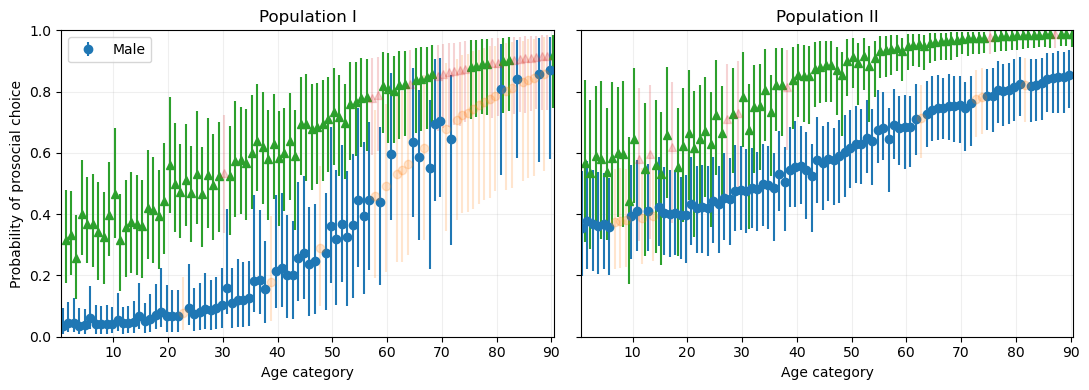

In [13]:
# -------------------------
# (a) Real population differences
# -------------------------
D_popdiff = build_pop_distributions_population_differences(Age_range)

# Simulate (balanced gender sampling: 0.5/0.5)
d_popdiff, SampleD_popdiff = simulate_dataset(
    D=D_popdiff, N=N, age_range=Age_range,
    p_male_pop1=0.5, p_male_pop2=0.5,
    p_logit_culture=p_logit_culture, b_age=b_age, b_gender=b_gender,
)

# True expected values
True_Value_popdiff = compute_true_expected(D_popdiff, p_logit_culture, b_age, b_gender)

# Prepare lists for population 1 and 2
d1_popdiff = {
    "N": N,
    "MA": MA,
    "gender": d_popdiff.query("soc_id==1")["gender"].to_numpy(),
    "age":    d_popdiff.query("soc_id==1")["age"].to_numpy(),
    "outcome":d_popdiff.query("soc_id==1")["outcome"].to_numpy(),
    "P_Pop":  (D_popdiff[0, :, :] * 1e9).astype(int),
    "P_other":(D_popdiff[1, :, :] * 1e9).astype(int),
}
d2_popdiff = {
    "N": N,
    "MA": MA,
    "gender": d_popdiff.query("soc_id==2")["gender"].to_numpy(),
    "age":    d_popdiff.query("soc_id==2")["age"].to_numpy(),
    "outcome":d_popdiff.query("soc_id==2")["outcome"].to_numpy(),
    "P_Pop":  (D_popdiff[1, :, :] * 1e9).astype(int),
    "P_other":(D_popdiff[0, :, :] * 1e9).astype(int),
}

# Fit empirical (simple) models
emp1_popdiff = fit_empirical(d1_popdiff["outcome"], seed=1)
emp2_popdiff = fit_empirical(d2_popdiff["outcome"], seed=1)

# Fit MRP-GP models
mrp1_popdiff = fit_mrp_gp(d1_popdiff["age"], d1_popdiff["gender"], d1_popdiff["outcome"],
                          d1_popdiff["P_Pop"], d1_popdiff["P_other"], MA, seed=1)
mrp2_popdiff = fit_mrp_gp(d2_popdiff["age"], d2_popdiff["gender"], d2_popdiff["outcome"],
                          d2_popdiff["P_Pop"], d2_popdiff["P_other"], MA, seed=1)

# Plot age curves for population differences
_ = plot_age_curves(mrp1_popdiff, mrp2_popdiff,
                    d_list_pop1=d1_popdiff, d_list_pop2=d2_popdiff,
                    title_left="Population I", title_right="Population II",
                    outpath=outdir/"age_curves_population_differences.png")

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'age_effect_g0'}>,
        <Axes: title={'center': 'age_effect_g0'}>],
       [<Axes: title={'center': 'age_effect_g1'}>,
        <Axes: title={'center': 'age_effect_g1'}>],
       [<Axes: title={'center': 'eta'}>, <Axes: title={'center': 'eta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'rho'}>, <Axes: title={'center': 'rho'}>],
       [<Axes: title={'center': 'age_effect'}>,
        <Axes: title={'center': 'age_effect'}>],
       [<Axes: title={'center': 'pred_p_m'}>,
        <Axes: title={'center': 'pred_p_m'}>],
       [<Axes: title={'center': 'pred_p_f'}>,
        <Axes: title={'center': 'pred_p_f'}>],
       [<Axes: title={'center': 'p_pop'}>,
        <Axes: title={'center': 'p_pop'}>],
       [<Axes: title={'center': 'p_other'}>,
        <Axes: title={'center': 'p_other'}>]], dtype=ob

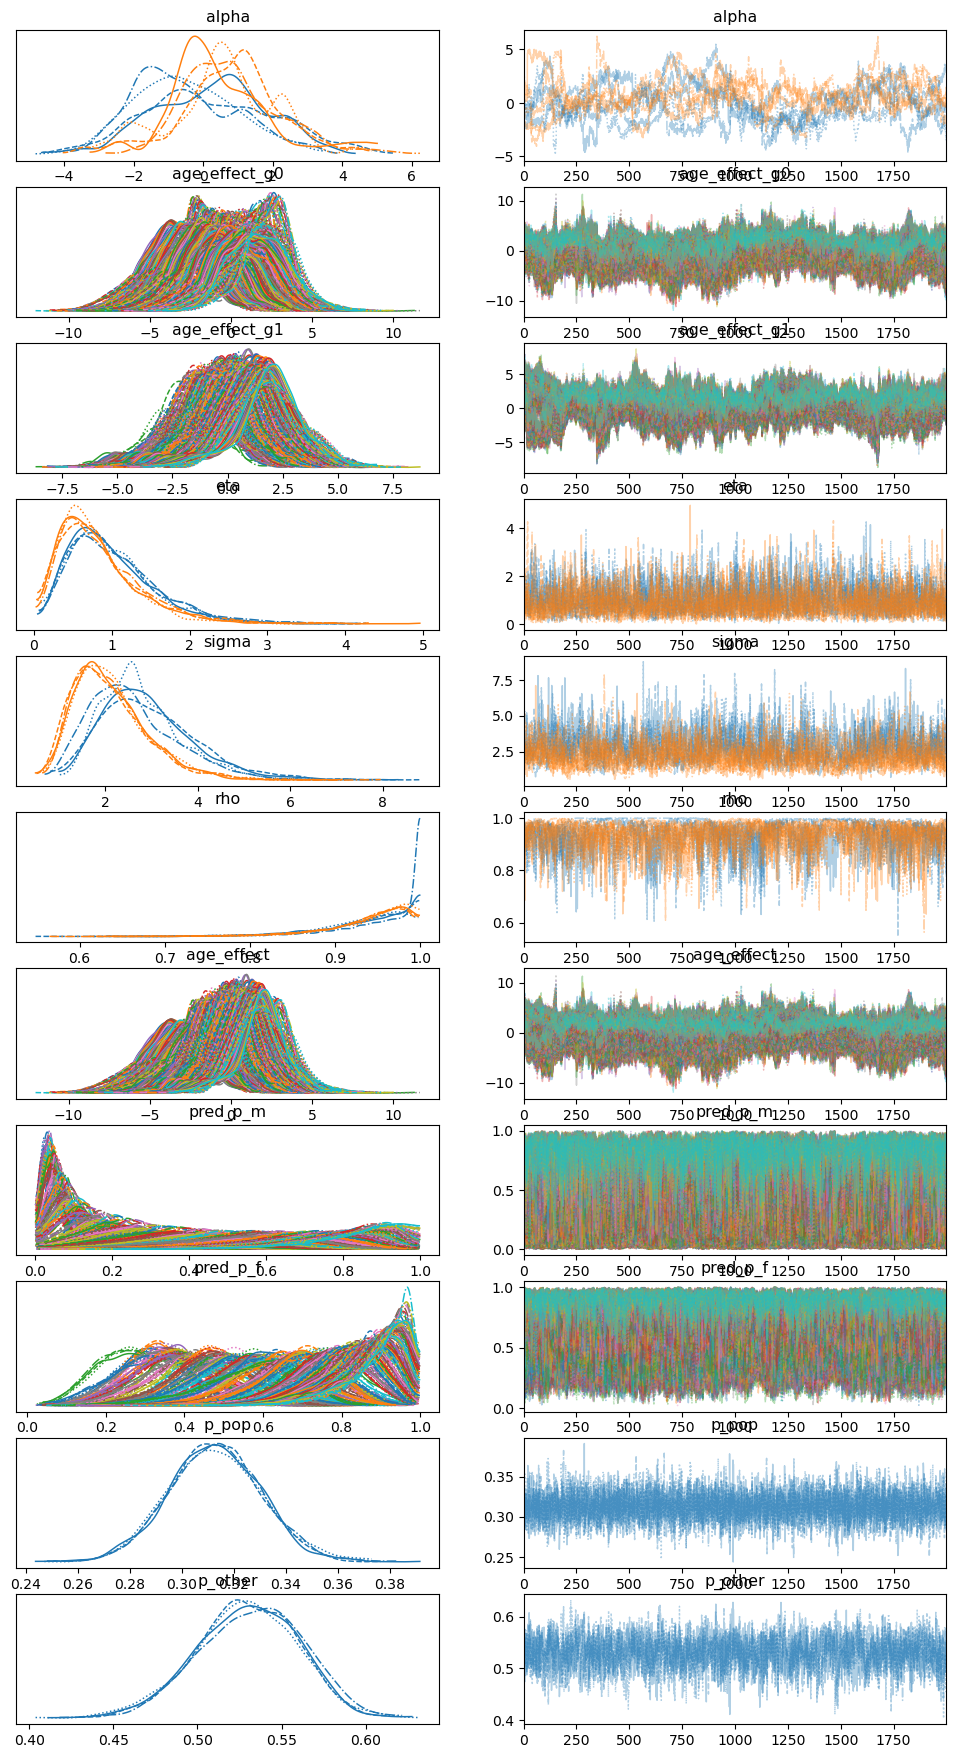

In [14]:
az.plot_trace(mrp1_popdiff)

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'age_effect_g0'}>,
        <Axes: title={'center': 'age_effect_g0'}>],
       [<Axes: title={'center': 'age_effect_g1'}>,
        <Axes: title={'center': 'age_effect_g1'}>],
       [<Axes: title={'center': 'eta'}>, <Axes: title={'center': 'eta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'rho'}>, <Axes: title={'center': 'rho'}>],
       [<Axes: title={'center': 'age_effect'}>,
        <Axes: title={'center': 'age_effect'}>],
       [<Axes: title={'center': 'pred_p_m'}>,
        <Axes: title={'center': 'pred_p_m'}>],
       [<Axes: title={'center': 'pred_p_f'}>,
        <Axes: title={'center': 'pred_p_f'}>],
       [<Axes: title={'center': 'p_pop'}>,
        <Axes: title={'center': 'p_pop'}>],
       [<Axes: title={'center': 'p_other'}>,
        <Axes: title={'center': 'p_other'}>]], dtype=ob

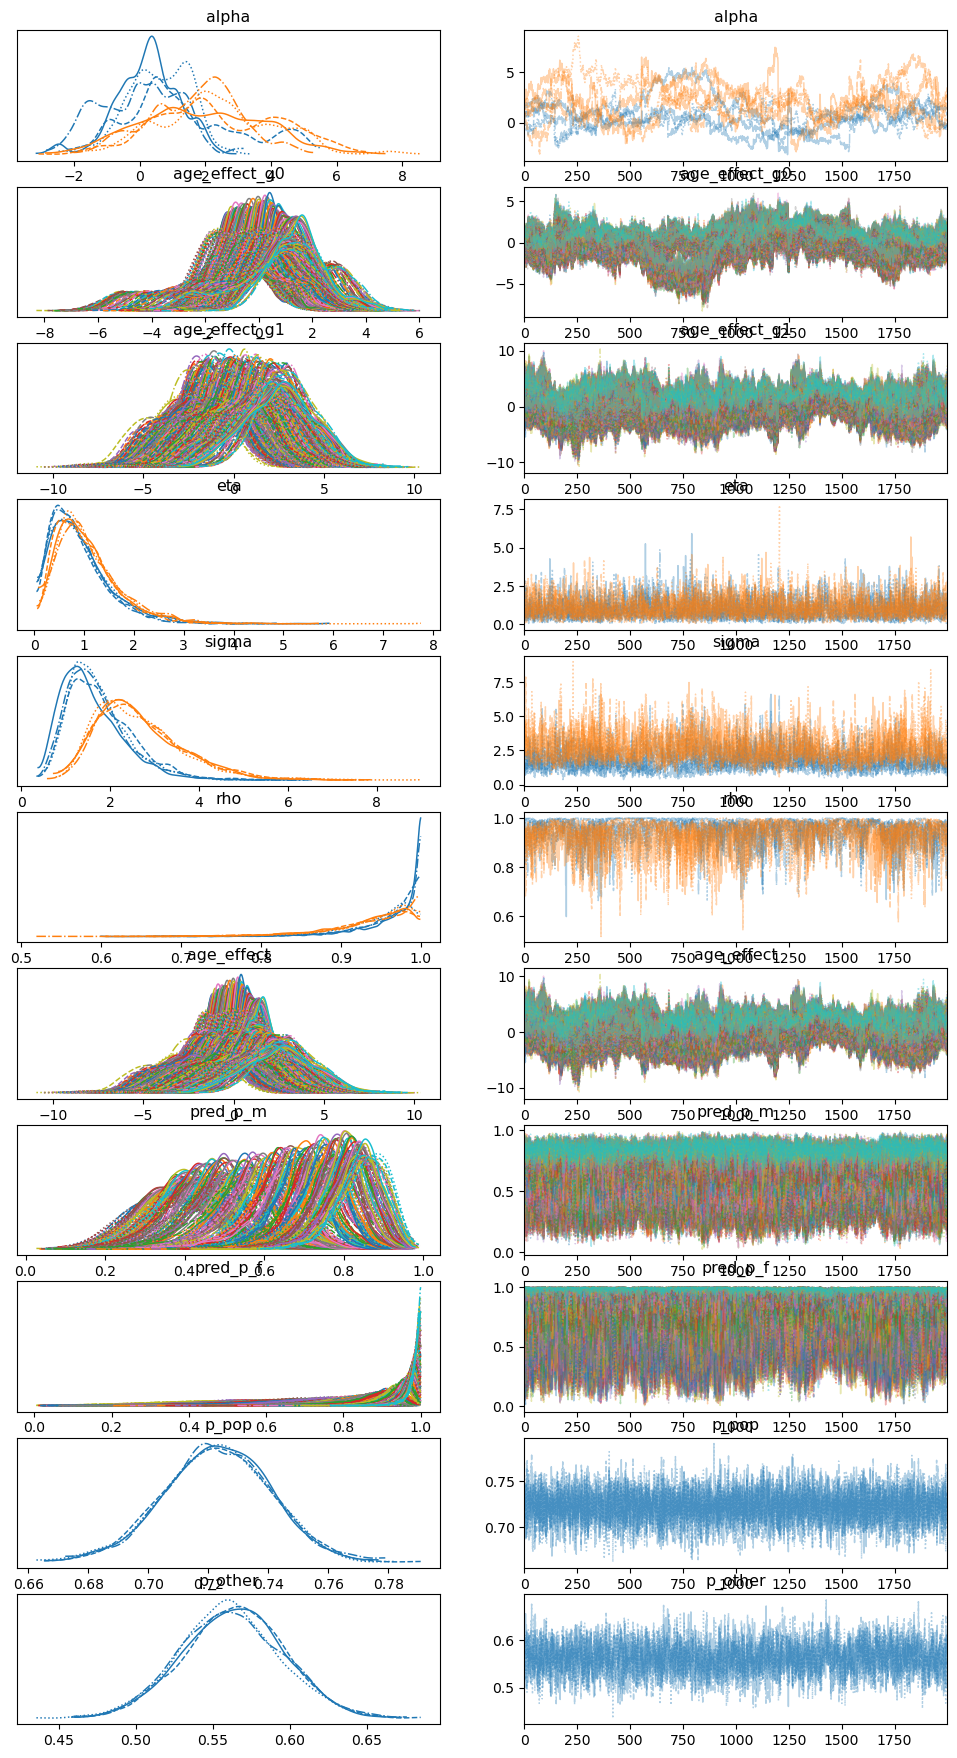

In [15]:
az.plot_trace(mrp2_popdiff)

array([[<Axes: title={'center': 'p_logit'}>,
        <Axes: title={'center': 'p_logit'}>],
       [<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

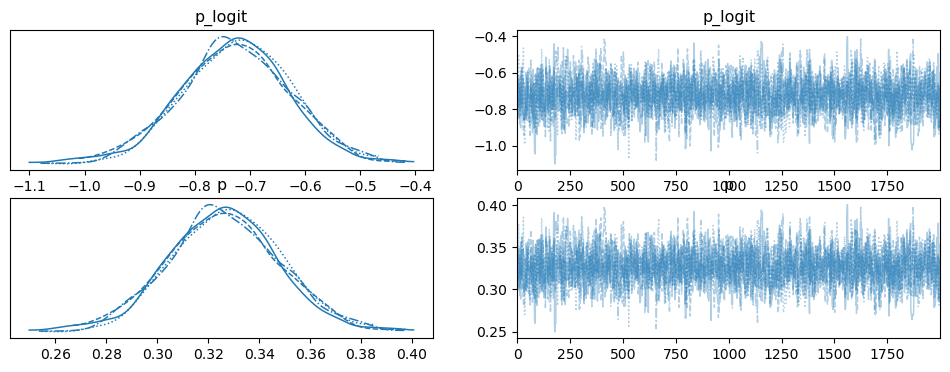

In [16]:
az.plot_trace(emp1_popdiff)

array([[<Axes: title={'center': 'p_logit'}>,
        <Axes: title={'center': 'p_logit'}>],
       [<Axes: title={'center': 'p'}>, <Axes: title={'center': 'p'}>]],
      dtype=object)

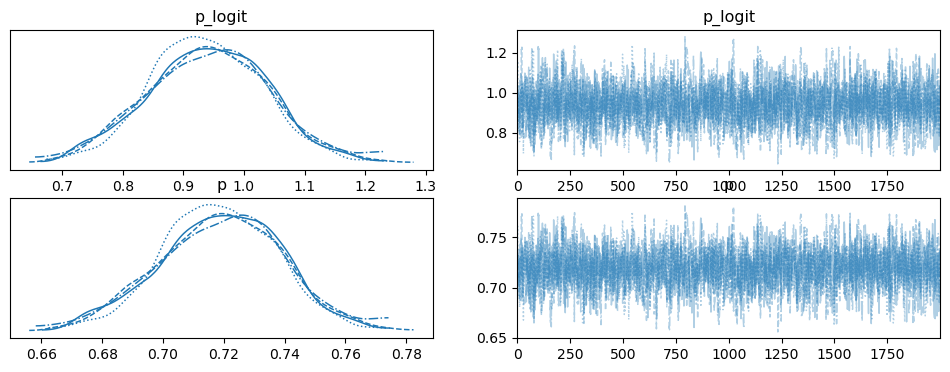

In [17]:
az.plot_trace(emp2_popdiff)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_logit]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_logit]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, eta, sigma, rho, age_effect_g0, age_effect_g1]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1198 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, eta, sigma, rho, age_effect_g0, age_effect_g1]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1962 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


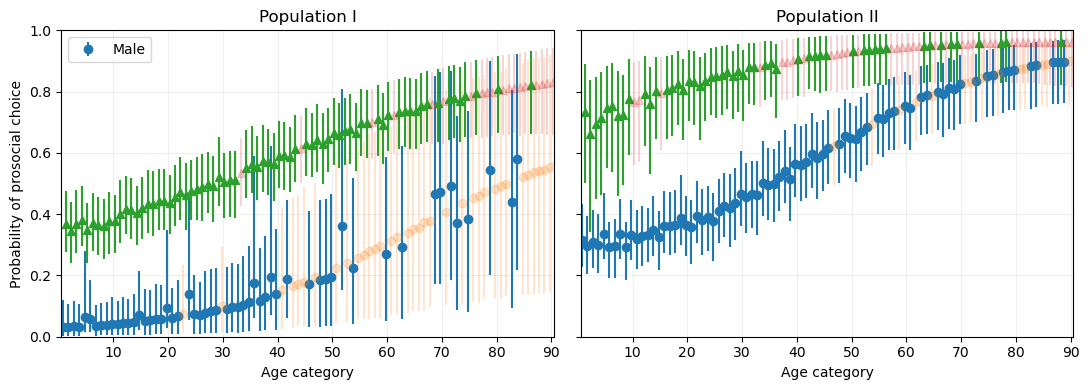

In [18]:
# -------------------------
# (b) Sampling differences (different gender sampling rates)
# -------------------------
D_samplediff = build_pop_distributions_sampling_differences(Age_range)

# Pop1: male 0.3, female 0.7; Pop2: male 0.8, female 0.2
d_samplediff, SampleD_samplediff = simulate_dataset(
    D=D_samplediff, N=N, age_range=Age_range,
    p_male_pop1=0.3, p_male_pop2=0.8,
    p_logit_culture=p_logit_culture, b_age=b_age, b_gender=b_gender,
)

True_Value_samplediff = compute_true_expected(D_samplediff, p_logit_culture, b_age, b_gender)

d1_samplediff = {
    "N": N,
    "MA": MA,
    "gender": d_samplediff.query("soc_id==1")["gender"].to_numpy(),
    "age":    d_samplediff.query("soc_id==1")["age"].to_numpy(),
    "outcome":d_samplediff.query("soc_id==1")["outcome"].to_numpy(),
    "P_Pop":  (D_samplediff[0, :, :] * 1e9).astype(int),
    "P_other":(D_samplediff[1, :, :] * 1e9).astype(int),
}
d2_samplediff = {
    "N": N,
    "MA": MA,
    "gender": d_samplediff.query("soc_id==2")["gender"].to_numpy(),
    "age":    d_samplediff.query("soc_id==2")["age"].to_numpy(),
    "outcome":d_samplediff.query("soc_id==2")["outcome"].to_numpy(),
    "P_Pop":  (D_samplediff[1, :, :] * 1e9).astype(int),
    "P_other":(D_samplediff[0, :, :] * 1e9).astype(int),
}

emp1_samplediff = fit_empirical(d1_samplediff["outcome"], seed=4)
emp2_samplediff = fit_empirical(d2_samplediff["outcome"], seed=4)

mrp1_samplediff = fit_mrp_gp(d1_samplediff["age"], d1_samplediff["gender"], d1_samplediff["outcome"],
                             d1_samplediff["P_Pop"], d1_samplediff["P_other"], MA, seed=4)
mrp2_samplediff = fit_mrp_gp(d2_samplediff["age"], d2_samplediff["gender"], d2_samplediff["outcome"],
                             d2_samplediff["P_Pop"], d2_samplediff["P_other"], MA, seed=4)

_ = plot_age_curves(mrp1_samplediff, mrp2_samplediff,
                    d_list_pop1=d1_samplediff, d_list_pop2=d2_samplediff,
                    title_left="Population I", title_right="Population II",
                    outpath=outdir/"age_curves_sampling_differences.png")

## PLotting

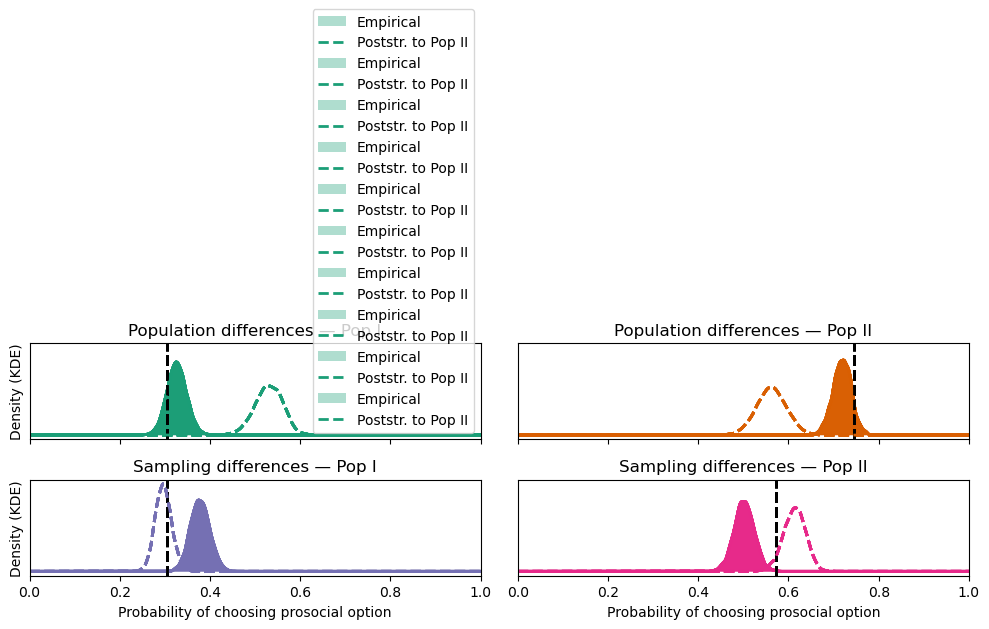

In [38]:
# Population differences, Pop I
samples_emp1 = inv_logit(az.extract(emp1_popdiff, var_names=["p_logit"]).values.ravel())
samples_ps1  = az.extract(mrp1_popdiff, var_names=["p_other"]).values.ravel()
plot_density(axes[0,0], samples_emp1, True_Value_popdiff[0], face="#1b9e77", edge="#1b9e77", label="Empirical", alpha=0.35, lw=2.0)
plot_density(axes[0,0], samples_ps1, None, face=None, edge="#1b9e77", label="Poststr. to Pop II", alpha=1.0, lw=2.0, linestyle='--')
axes[0,0].set_title("Population differences — Pop I")
axes[0,0].legend()

# Population differences, Pop II
samples_emp2 = inv_logit(az.extract(emp2_popdiff, var_names=["p_logit"]).values.ravel())
samples_ps2  = az.extract(mrp2_popdiff, var_names=["p_other"]).values.ravel()
plot_density(axes[0,1], samples_emp2, True_Value_popdiff[1], face="#d95f02", edge="#d95f02", label="Empirical", alpha=0.35, lw=2.0)
plot_density(axes[0,1], samples_ps2, None, face=None, edge="#d95f02", label="Poststr. to Pop I", alpha=1.0, lw=2.0, linestyle='--')
axes[0,1].set_title("Population differences — Pop II")

# Sampling differences, Pop I
samples_emp1_s = inv_logit(az.extract(emp1_samplediff, var_names=["p_logit"]).values.ravel())
samples_ps1_s  = az.extract(mrp1_samplediff, var_names=["p_pop"]).values.ravel()
plot_density(axes[1,0], samples_emp1_s, True_Value_samplediff[0], face="#7570b3", edge="#7570b3", label="Empirical", alpha=0.35, lw=2.0)
plot_density(axes[1,0], samples_ps1_s, None, face=None, edge="#7570b3", label="Poststr. to Pop I", alpha=1.0, lw=2.0, linestyle='--')
axes[1,0].set_title("Sampling differences — Pop I")

# Sampling differences, Pop II
samples_emp2_s = inv_logit(az.extract(emp2_samplediff, var_names=["p_logit"]).values.ravel())
samples_ps2_s  = az.extract(mrp2_samplediff, var_names=["p_pop"]).values.ravel()
plot_density(axes[1,1], samples_emp2_s, True_Value_samplediff[1], face="#e7298a", edge="#e7298a", label="Empirical", alpha=0.35, lw=2.0)
plot_density(axes[1,1], samples_ps2_s, None, face=None, edge="#e7298a", label="Poststr. to Pop II", alpha=1.0, lw=2.0, linestyle='--')
axes[1,1].set_title("Sampling differences — Pop II")

for ax in axes[-1, :]:
    ax.set_xlabel("Probability of choosing prosocial option")
for ax in axes[:, 0]:
    ax.set_ylabel("Density (KDE)")

fig.tight_layout()
fig.savefig(outdir/"densities_empirical_vs_poststratified.png", dpi=200)
fig

Saved figures to: /mnt/c/Users/risto/projects/Cross-Cultural-Generalizability/outputs_python


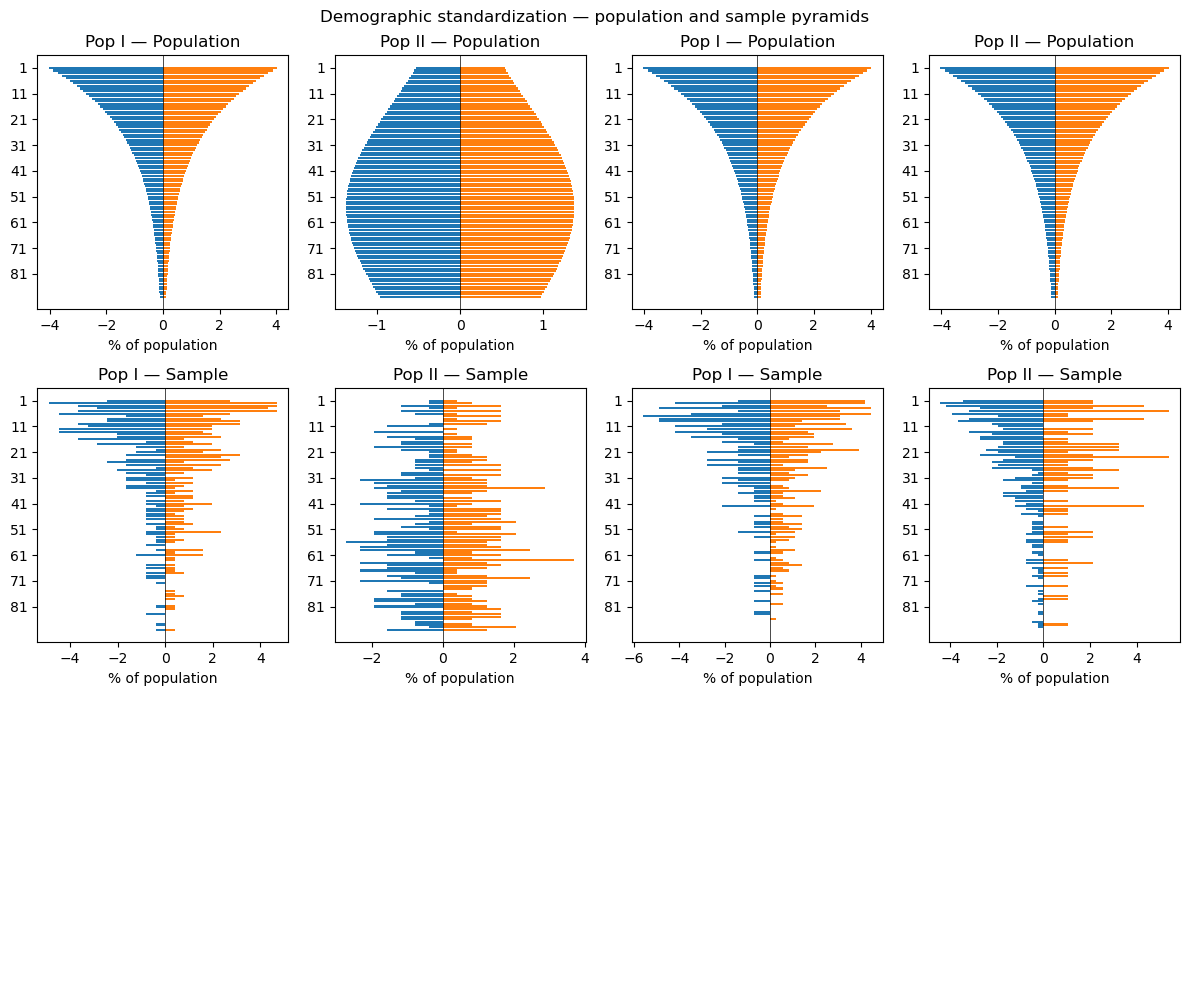

In [21]:
# -------------------------
# Population pyramid visuals (quick approximation)
# -------------------------
fig, axes = plt.subplots(3, 4, figsize=(12, 10))
ages = Age_range

# Population differences — population pyramids
pyramid_plot(axes[0,0], D_popdiff[0,0,:], D_popdiff[0,1,:], ages, title="Pop I — Population")
pyramid_plot(axes[0,1], D_popdiff[1,0,:], D_popdiff[1,1,:], ages, title="Pop II — Population")

# Sampling differences — population pyramids (same age shape)
pyramid_plot(axes[0,2], D_samplediff[0,0,:], D_samplediff[0,1,:], ages, title="Pop I — Population")
pyramid_plot(axes[0,3], D_samplediff[1,0,:], D_samplediff[1,1,:], ages, title="Pop II — Population")

# Sample pyramids for popdiff
pyramid_plot(axes[1,0], SampleD_popdiff[0,0,:], SampleD_popdiff[0,1,:], ages, title="Pop I — Sample")
pyramid_plot(axes[1,1], SampleD_popdiff[1,0,:], SampleD_popdiff[1,1,:], ages, title="Pop II — Sample")

# Sample pyramids for samplediff
pyramid_plot(axes[1,2], SampleD_samplediff[0,0,:], SampleD_samplediff[0,1,:], ages, title="Pop I — Sample")
pyramid_plot(axes[1,3], SampleD_samplediff[1,0,:], SampleD_samplediff[1,1,:], ages, title="Pop II — Sample")

# Empty row for spacing / captions (or could add legends)
axes[2,0].axis('off'); axes[2,1].axis('off'); axes[2,2].axis('off'); axes[2,3].axis('off')

fig.suptitle("Demographic standardization — population and sample pyramids", y=0.98)
fig.tight_layout()
fig.savefig(outdir/"pyramids.png", dpi=200)

print("Saved figures to:", outdir.resolve())


## Idea, what if two effects are mixed?

In [49]:
D_both = build_pop_distributions_population_differences(Age_range)

# sums to 1 across ages for each (pop,gender)
D_both.sum(axis=2)  # -> array([[1., 1.],[1., 1.]])

# Pop 2 should be older-tilted vs Pop 1
ages = np.arange(1, D_both.shape[-1]+1)
mean_age_pop1 = (ages * (D_both[0,0,:]/D_both[0,0,:].sum())).sum()
mean_age_pop2 = (ages * (D_both[1,0,:]/D_both[1,0,:].sum())).sum()
print(mean_age_pop1, mean_age_pop2)  # pop2 > pop1

22.975117971794514 49.13054478629169


In [50]:
# AND different gender sampling (e.g., Pop1 oversamples females, Pop2 oversamples males):
d_both, SampleD_both = simulate_dataset(
    D=D_both, N=N, age_range=Age_range,
    p_male_pop1=0.3,   # 30% male in sample for Pop1
    p_male_pop2=0.8,   # 80% male in sample for Pop2
    p_logit_culture=p_logit_culture, b_age=b_age, b_gender=b_gender,
)

In [53]:
# Build Stan-like lists & fit as usual:
d1_both = {
    "N": N, "MA": MA,
    "gender": d_both.query("soc_id==1")["gender"].to_numpy(),
    "age":    d_both.query("soc_id==1")["age"].to_numpy(),
    "outcome":d_both.query("soc_id==1")["outcome"].to_numpy(),
    "P_Pop":  (D_both[0,:,:] * 1e9).astype(int),
    "P_other":(D_both[1,:,:] * 1e9).astype(int),
}
d2_both = {
    "N": N, "MA": MA,
    "gender": d_both.query("soc_id==2")["gender"].to_numpy(),
    "age":    d_both.query("soc_id==2")["age"].to_numpy(),
    "outcome":d_both.query("soc_id==2")["outcome"].to_numpy(),
    "P_Pop":  (D_both[1,:,:] * 1e9).astype(int),
    "P_other":(D_both[0,:,:] * 1e9).astype(int),
}

In [73]:
emp1_both_samplediff = fit_empirical(d1_both["outcome"], seed=4)
emp2_both_samplediff = fit_empirical(d2_both["outcome"], seed=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_logit]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_logit]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 2 seconds.


In [54]:
mrp1_both = fit_mrp_gp(d1_both["age"], d1_both["gender"], d1_both["outcome"],
                       d1_both["P_Pop"], d1_both["P_other"], MA, seed=7)
mrp2_both = fit_mrp_gp(d2_both["age"], d2_both["gender"], d2_both["outcome"],
                       d2_both["P_Pop"], d2_both["P_other"], MA, seed=7)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, eta, sigma, rho, age_effect_g0, age_effect_g1]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1003 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, eta, sigma, rho, age_effect_g0, age_effect_g1]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 4931 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


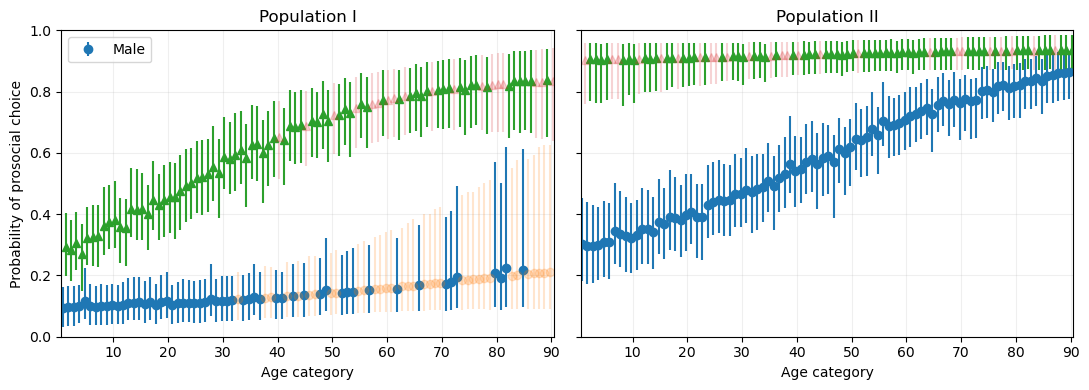

In [69]:
# Plot age curves for population differences
_ = plot_age_curves(mrp1_both, mrp2_both,
                    d_list_pop1=d1_both, d_list_pop2=d2_both,
                    title_left="Population I", title_right="Population II",
                    outpath=outdir/"age_curves_population_differences_sampling_differences.png")

In [56]:
df_summry_mrp1_both=az.summary(mrp1_both)

In [58]:
df_summry_mrp1_both[df_summry_mrp1_both.r_hat>1.01].shape

(453, 9)

In [57]:
df_summry_mrp2_both=az.summary(mrp2_both)

In [59]:
df_summry_mrp2_both[df_summry_mrp2_both.r_hat>1.01].shape

(398, 9)

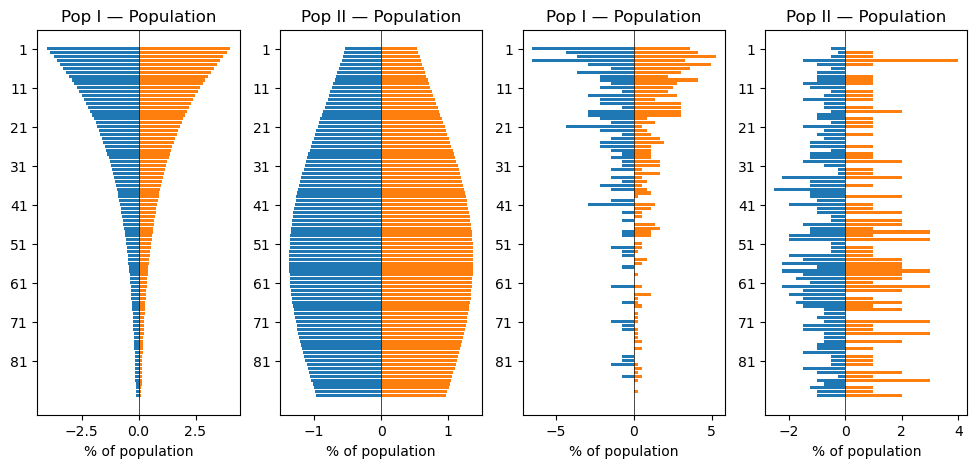

In [68]:
# -------------------------
# Population pyramid visuals (quick approximation)
# -------------------------
fig, axes = plt.subplots(1, 4, figsize=(12, 5))
ages = Age_range

# Population differences — population pyramids
pyramid_plot(axes[0], D_both[0,0,:], D_both[0,1,:], ages, title="Pop I — Population")
pyramid_plot(axes[1], D_both[1,0,:], D_both[1,1,:], ages, title="Pop II — Population")

# Sampling differences — population pyramids (same age shape)
pyramid_plot(axes[2], SampleD_both[0,0,:], SampleD_both[0,1,:], ages, title="Pop I — Population")
pyramid_plot(axes[3], SampleD_both[1,0,:], SampleD_both[1,1,:], ages, title="Pop II — Population")
